In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import random
from IPython.display import display, Markdown, Latex
pd.options.mode.chained_assignment = None

In [2]:
# Load the data
df = pd.read_csv("pupper_2026-04-29_itslog_summary.csv")
orig = df

In [3]:
def getter(op, val):
    return df.loc[(df['operation'] == op), val].item()

# Demo App

In [4]:
# App metadata
display(Markdown('**App name**: local postman'))
display(Markdown('**App created**: ' + getter('app_created', 'value')))
display(Markdown('**App updated**: ' + getter('app_updated', 'value')))
display(Markdown('**Grant type**: ' + getter('app_data_access_type', 'value')))
display(Markdown('**Total synth benes**: ' + getter('total_synth_bene_cnt', 'value')))


**App name**: local postman

**App created**: 2026-04-27T21:42:08

**App updated**: 2026-04-29T20:25:02

**Grant type**: THIRTEEN_MONTH

**Total synth benes**: 22

## Overview

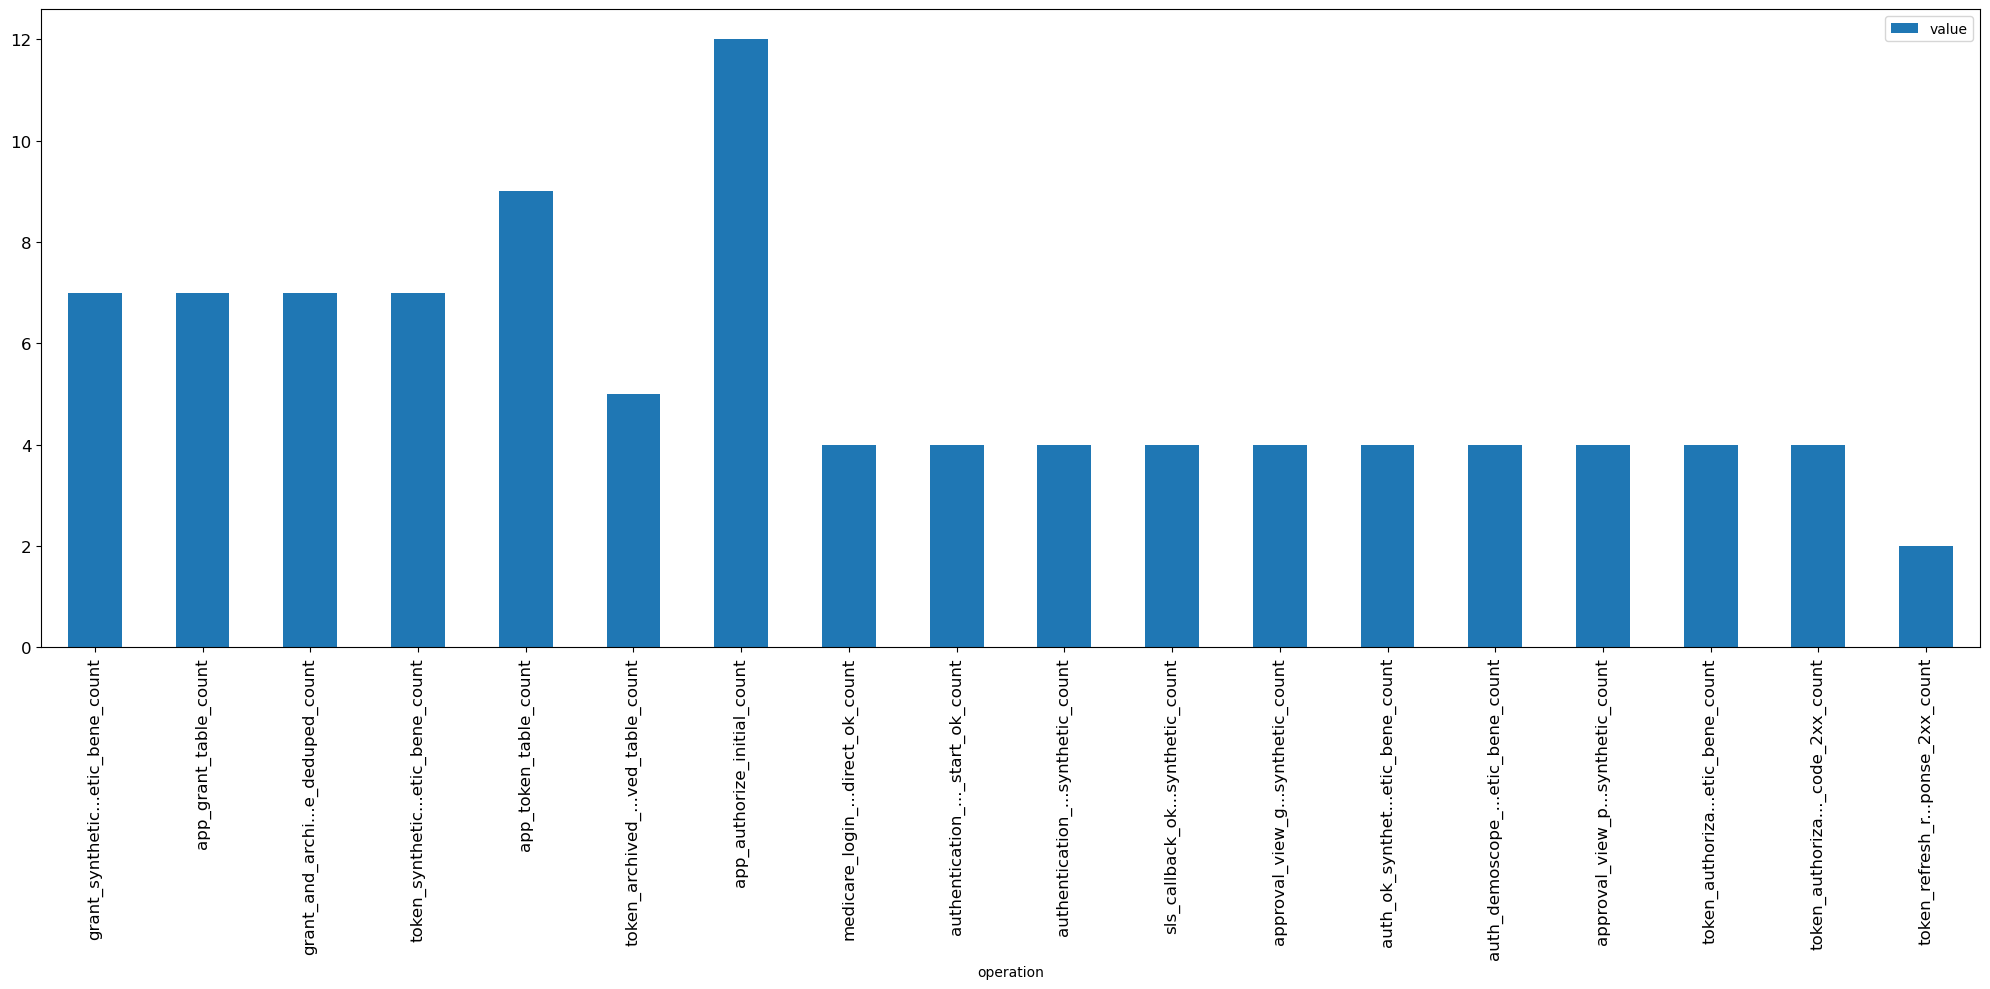

In [5]:
# Counts
app_level = df[(~df['operation'].str.contains('app_fhir')) & (df['tags'].str.contains('2.')) & (df['value'] != "0") & (df['value'].str.isdigit()) & (df['operation'].str.contains('count'))]
app_level["value"] = pd.to_numeric(app_level["value"])
app_level['operation'] = app_level['operation'].map(lambda s: s if len(s) < 30 else s[4:19] + "..." + s[-15:]) # )
plt.rcParams['figure.figsize'] = (20, 10)
app_level.plot.bar(x='operation', y='value', fontsize=12, rot=90)
plt.tight_layout()
plt.show()

## How many hits per endpoint? (v1, v2, v3)

<Axes: xlabel='operation'>

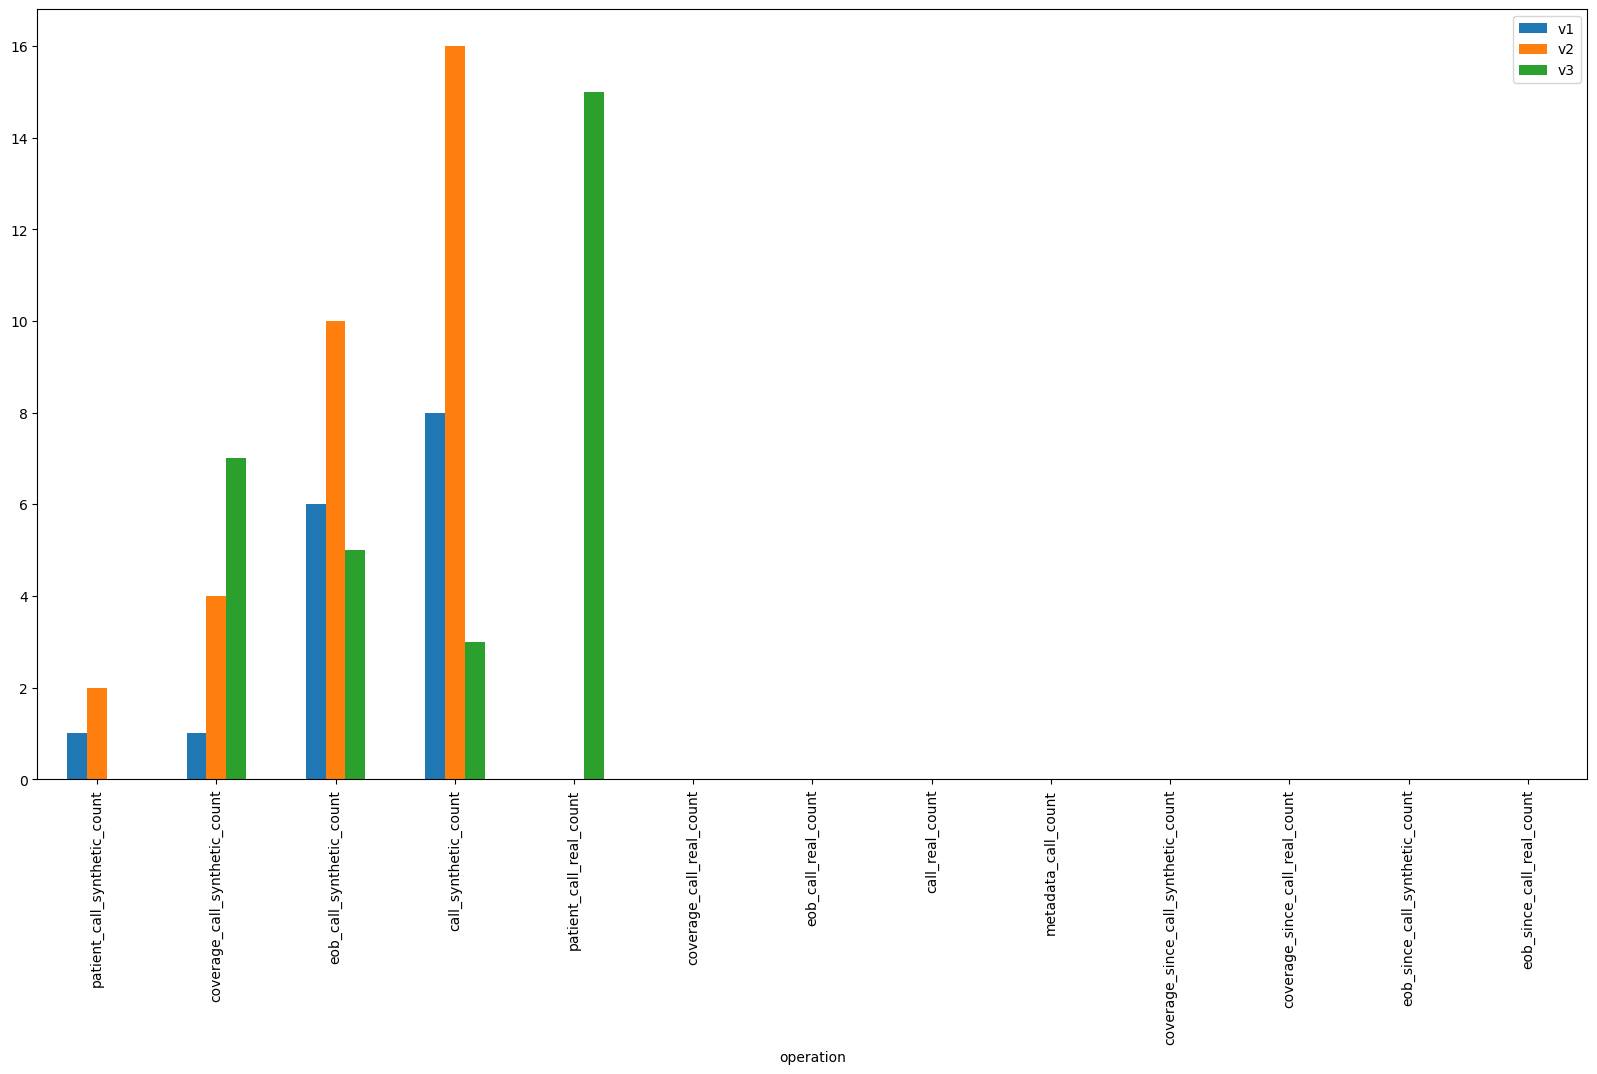

In [6]:
# Endpoints
v1 = df[df['operation'].str.startswith('fhir_v1')]
v2 = df[df['operation'].str.startswith('fhir_v2')]
v3 = df[df['operation'].str.startswith('fhir_v3')]
v1['value'] = pd.to_numeric(v1['value'])
v2['value'] = pd.to_numeric(v2['value'])
v3['value'] = pd.to_numeric(v3['value'])

# labels = app_level['operation'] = app_level['operation'].map(lambda s: s[4:19] + "..." + s[-15:])
labels = v1['operation'].map(lambda s: s[8:])

#print(len(v1['value'].tolist()), len(v2['value'].tolist()), len(v3['value'].tolist()))
#print(v1['value'].tolist(), v2['value'].tolist(), v3['value'].tolist())

side_by_each = pd.DataFrame({
    "v1": v1['value'].tolist(),
    "v2": v2['value'].tolist(),
    "v3": v3['value'].tolist()[0:13]
}, index=labels)

side_by_each.plot(kind='bar')

## Hits in the past month (v1, v2, v3)

['patient_call_synthetic_count', 'coverage_call_synthetic_count', 'eob_call_synthetic_count', 'call_synthetic_count', 'patient_call_real_count', 'coverage_call_real_count', 'eob_call_real_count', 'call_real_count', 'metadata_call_count', 'coverage_since_call_synthetic_count', 'coverage_since_call_real_count', 'eob_since_call_synthetic_count', 'eob_since_call_real_count']


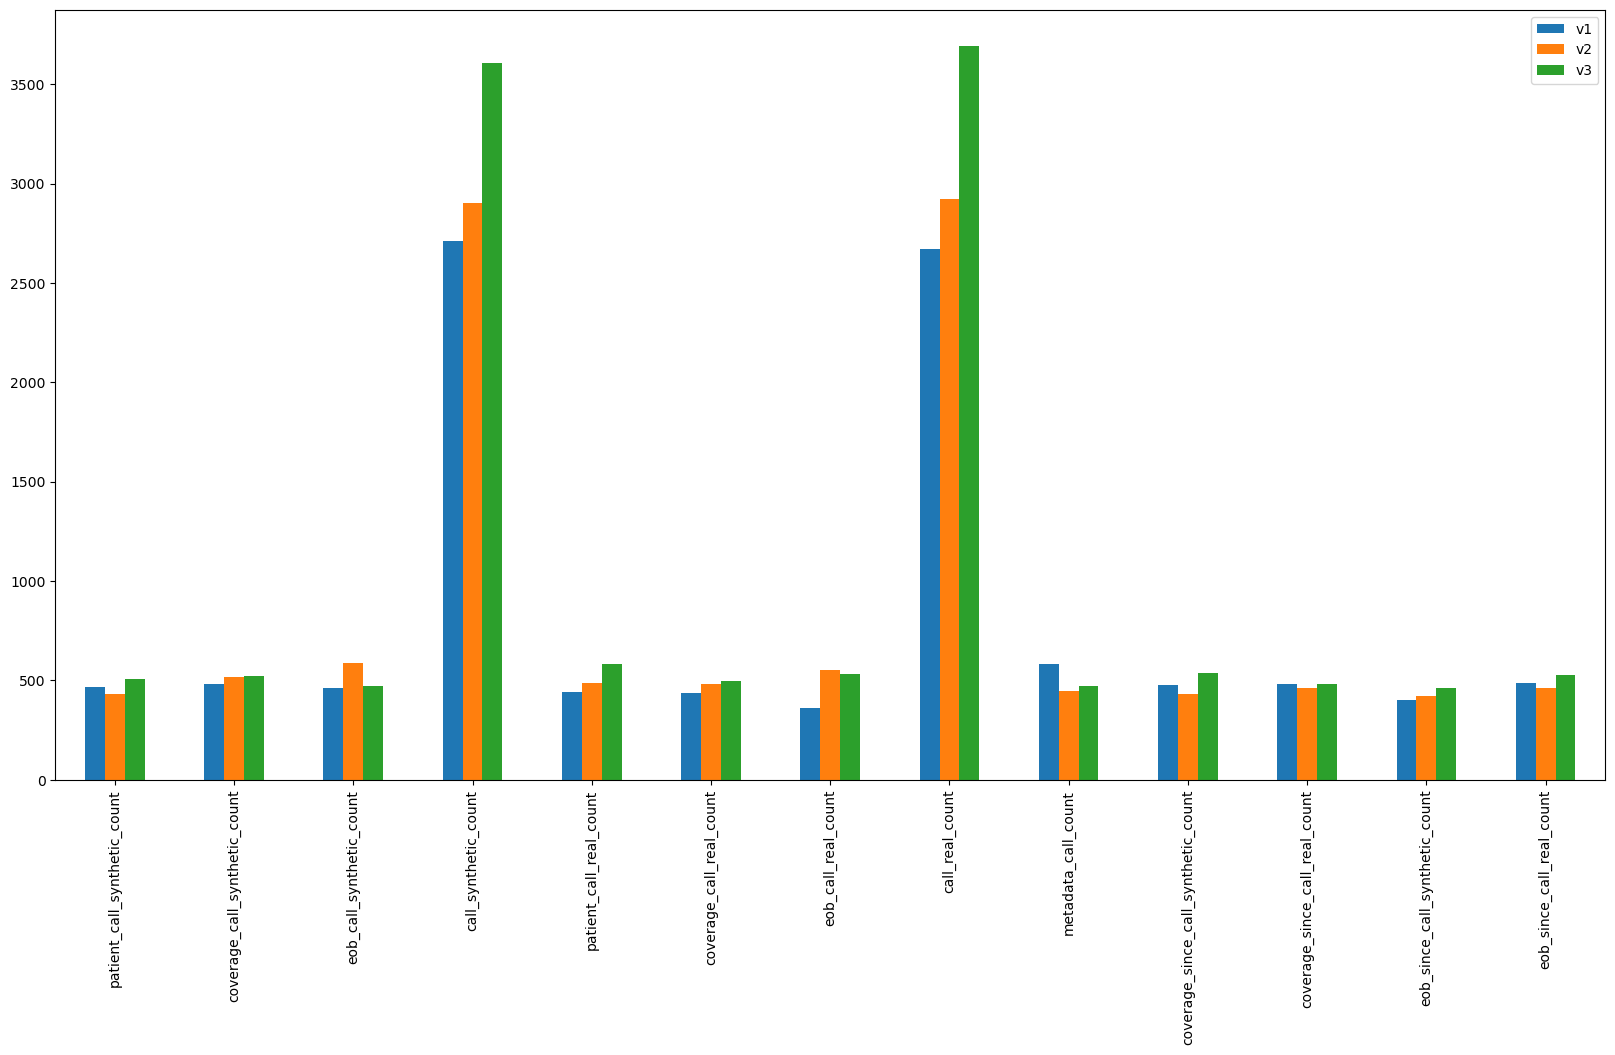

In [7]:
# Extend to a fake month
# id,last_run,date,key_id,operation,tags,value,count,hash
df = orig
for i in range(30):
    nextdf = df[df['date'] == '2026-04-29']
    next_day = datetime.datetime.strptime('2026-04-29', "%Y-%m-%d") + datetime.timedelta(days=i+1)
    nextdf['date'] = nextdf['date'].map(lambda d: f"{next_day:%Y-%m-%d}")
    # Randomize values for all totals in the new frame
    nextdf['value'] = nextdf['value'].map(lambda v: random.randint(3,30))
    df = pd.concat([df, nextdf])
# Get the unique keys
keys = list(map(lambda s: s[8:], df[df['operation'].str.startswith('fhir_v1')]['operation'].unique().tolist()))
# Strip the version info
print(keys)

# Now, sum for each unique key, by version
frames = {}
for ver in ['v1', 'v2', 'v3']:
    frames[ver] = pd.DataFrame(columns=['operation', 'value'])
    for key in keys:
        newv = sum(map(lambda s: int(s), df[df['operation'].str.startswith(f'fhir_{ver}') & df['operation'].str.contains(key)]['value'].tolist()))
        frames[ver].loc[len(frames[ver])] = {'operation': f'fhir_{ver}_{key}', 'value': newv}

consolidated = pd.DataFrame({
    "v1": frames['v1']['value'].tolist(),
    "v2": frames['v2']['value'].tolist(),
    "v3": frames['v3']['value'].tolist()
}, index=keys)

_ = consolidated.plot(kind='bar')

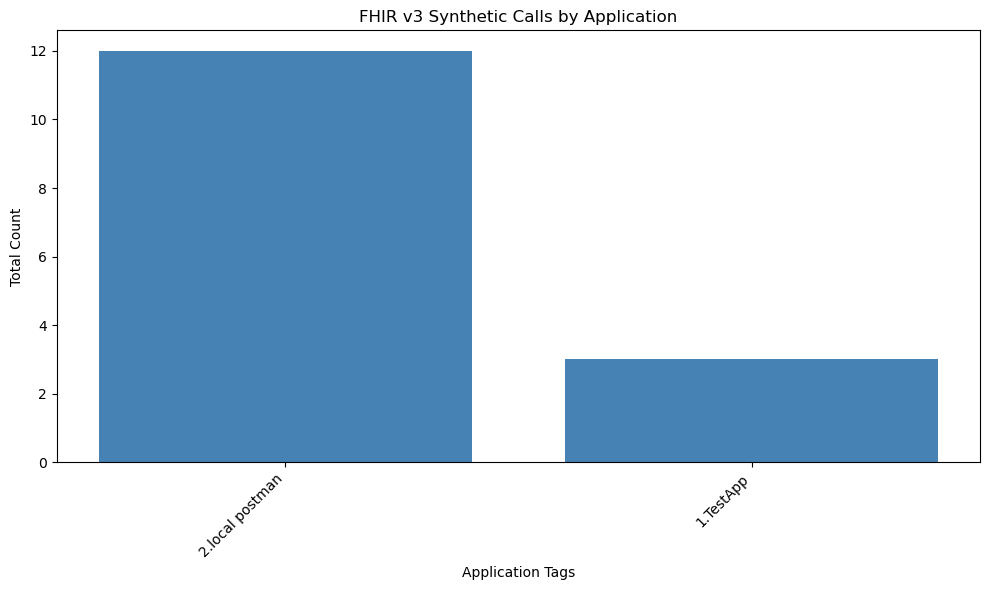

Chart 1 data points: 2
tags
2.local postman    12
1.TestApp           3
Name: value, dtype: int64


In [8]:
# Chart 1: Filter for app_fhir_v3_call_synthetic_count with tags
df = orig
chart1_data = df[
    (df['operation'] == 'app_fhir_v3_call_synthetic_count') & 
    (df['tags'].notna()) & 
    (df['tags'] != '')
].copy()

chart1_data['value'] = pd.to_numeric(chart1_data['value'], errors='coerce')
chart1_grouped = chart1_data.groupby('tags')['value'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(chart1_grouped.index, chart1_grouped.values, color='steelblue')
ax.set_title('FHIR v3 Synthetic Calls by Application')
ax.set_xlabel('Application Tags')
ax.set_ylabel('Total Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Chart 1 data points: {len(chart1_grouped)}")
print(chart1_grouped)

In [ ]:
# Chart 2: Filter for fhir_v3 operations with null/empty tags
chart2_data = df[
    (df['operation'].str.contains('fhir_v3', na=False)) & 
    (df['tags'].isna() | (df['tags'] == ''))
].copy()

chart2_data['value'] = pd.to_numeric(chart2_data['value'], errors='coerce')
chart2_grouped = chart2_data.groupby('operation')['value'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(chart2_grouped.index, chart2_grouped.values, color='coral')
ax.set_title('System-Level FHIR v3 Operations (No App Tags)')
ax.set_xlabel('Operation Type')
ax.set_ylabel('Total Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Chart 2 data points: {len(chart2_grouped)}")
print(chart2_grouped)